In [1]:
import pandas as pd
import numpy as np
import duckdb
import os

DATA_DIR = '../data/fma_metadata/'

In [3]:
tracks = pd.read_csv(os.path.join(DATA_DIR, 'tracks.csv'), index_col=0, header=[0,1])
print("Shape:", tracks.shape)
print("\nTop-level column groups:", tracks.columns.get_level_values(0).unique().tolist())

Shape: (106574, 52)

Top-level column groups: ['album', 'artist', 'set', 'track']


In [5]:
print(tracks['track'].columns.tolist())

['bit_rate', 'comments', 'composer', 'date_created', 'date_recorded', 'duration', 'favorites', 'genre_top', 'genres', 'genres_all', 'information', 'interest', 'language_code', 'license', 'listens', 'lyricist', 'number', 'publisher', 'tags', 'title']


In [6]:
print(tracks['album'].columns.tolist())

['comments', 'date_created', 'date_released', 'engineer', 'favorites', 'id', 'information', 'listens', 'producer', 'tags', 'title', 'tracks', 'type']


In [7]:
echonest = pd.read_csv(os.path.join(DATA_DIR,'echonest.csv'), index_col=0, header=[0,1,2])
print("Shape:", echonest.shape)
print("\nTop-level groups:", echonest.columns.get_level_values(0).unique().tolist())
print("Second level:", echonest.columns.get_level_values(1).unique().tolist())

Shape: (13129, 249)

Top-level groups: ['echonest']
Second level: ['audio_features', 'metadata', 'ranks', 'social_features', 'temporal_features']


In [8]:
audio_features = echonest['echonest']['audio_features']
print("Audio feature columns:", audio_features.columns.tolist())
print("\nShape:", audio_features.shape)
print("First few rows:")
audio_features.head()

Audio feature columns: ['acousticness', 'danceability', 'energy', 'instrumentalness', 'liveness', 'speechiness', 'tempo', 'valence']

Shape: (13129, 8)
First few rows:


,acousticness,danceability,energy,instrumentalness,liveness,speechiness,tempo,valence
track_id,,,,,,,,
2,0.416675,0.675894,0.634476,0.010628,0.177647,0.159310,165.922,0.576661
3,0.374408,0.528643,0.817461,0.001851,0.105880,0.461818,126.957,0.269240
5,0.043567,0.745566,0.701470,0.000697,0.373143,0.124595,100.260,0.621661
10,0.951670,0.658179,0.924525,0.965427,0.115474,0.032985,111.562,0.963590
134,0.452217,0.513238,0.560410,0.019443,0.096567,0.525519,114.290,0.894072


In [9]:
print("Null counts in audio features:")
print(audio_features.isnull().sum())

Null counts in audio features:
acousticness        0
danceability        0
energy              0
instrumentalness    0
liveness            0
speechiness         0
tempo               0
valence             0
dtype: int64


In [11]:
audio_features.describe()

,acousticness,danceability,energy,instrumentalness,liveness,speechiness,tempo,valence
count,1.312900e+04,13129.000000,13129.000000,13129.000000,13129.000000,13129.000000,13129.000000,13129.000000
mean,5.246876e-01,0.487290,0.537516,0.640536,0.187804,0.099174,123.080061,0.439761
std,3.837186e-01,0.190148,0.278049,0.361430,0.158051,0.137381,35.015137,0.276028
min,9.035000e-07,0.051307,0.000020,0.000000,0.025297,0.022324,12.753000,0.000010
25%,1.037726e-01,0.344759,0.321300,0.323466,0.101406,0.036932,95.967000,0.197321
50%,5.739848e-01,0.485635,0.549113,0.838134,0.119002,0.049019,120.057000,0.417743
75%,9.207270e-01,0.629094,0.776254,0.918244,0.211041,0.085452,145.318000,0.665575
max,9.957965e-01,0.968645,0.999964,0.998016,0.980330,0.966177,251.072000,0.999990


In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

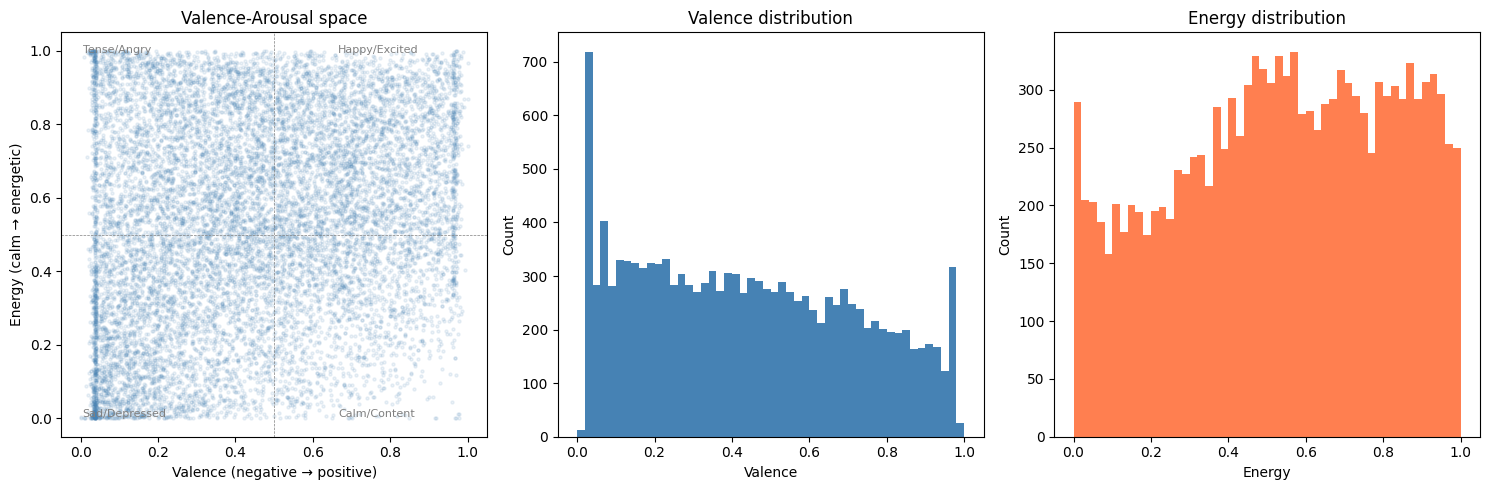

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].scatter(audio_features['valence'], 
                audio_features['energy'], 
                alpha=0.1, s=5, color='steelblue')
axes[0].set_xlabel('Valence (negative → positive)')
axes[0].set_ylabel('Energy (calm → energetic)')
axes[0].set_title('Valence-Arousal space')
axes[0].axhline(0.5, color='gray', linestyle='--', linewidth=0.5)
axes[0].axvline(0.5, color='gray', linestyle='--', linewidth=0.5)

axes[0].text(0.05, 0.95, 'Tense/Angry', transform=axes[0].transAxes, 
             fontsize=8, color='gray')
axes[0].text(0.65, 0.95, 'Happy/Excited', transform=axes[0].transAxes, 
             fontsize=8, color='gray')
axes[0].text(0.05, 0.05, 'Sad/Depressed', transform=axes[0].transAxes, 
             fontsize=8, color='gray')
axes[0].text(0.65, 0.05, 'Calm/Content', transform=axes[0].transAxes, 
             fontsize=8, color='gray')

axes[1].hist(audio_features['valence'], bins=50, color='steelblue', edgecolor='none')
axes[1].set_xlabel('Valence')
axes[1].set_ylabel('Count')
axes[1].set_title('Valence distribution')

axes[2].hist(audio_features['energy'], bins=50, color='coral', edgecolor='none')
axes[2].set_xlabel('Energy')
axes[2].set_ylabel('Count')
axes[2].set_title('Energy distribution')

plt.tight_layout()
plt.savefig('../data/va_space.png', dpi=150, bbox_inches='tight')
plt.show()

In [25]:
corr = audio_features.corr().round(2)
print(corr)

                  acousticness  danceability  energy  instrumentalness  \
acousticness              1.00         -0.19   -0.48              0.11   
danceability             -0.19          1.00    0.05             -0.12   
energy                   -0.48          0.05    1.00             -0.00   
instrumentalness          0.11         -0.12   -0.00              1.00   
liveness                  0.04         -0.14    0.05             -0.06   
speechiness               0.04          0.17   -0.01             -0.22   
tempo                    -0.11         -0.09    0.23              0.02   
valence                  -0.09          0.43    0.22             -0.15   

                  liveness  speechiness  tempo  valence  
acousticness          0.04         0.04  -0.11    -0.09  
danceability         -0.14         0.17  -0.09     0.43  
energy                0.05        -0.01   0.23     0.22  
instrumentalness     -0.06        -0.22   0.02    -0.15  
liveness              1.00         0.07  -0

In [26]:
track_info = tracks['track'][['title', 'genre_top', 'duration']].copy()
artist_info = tracks['artist'][['name']].copy()
artist_info.columns = ['artist_name']

In [27]:
catalog = pd.concat([track_info, artist_info], axis=1)

In [28]:
print("Catalog shape:", catalog.shape)
print("Echonest shape:", audio_features.shape)

Catalog shape: (106574, 4)
Echonest shape: (13129, 8)


In [29]:
catalog = catalog.join(audio_features, how='inner')

In [30]:
print("After join:", catalog.shape)
print("\nColumns:", catalog.columns.tolist())
print("\nNull check:")
print(catalog.isnull().sum())

After join: (13129, 12)

Columns: ['title', 'genre_top', 'duration', 'artist_name', 'acousticness', 'danceability', 'energy', 'instrumentalness', 'liveness', 'speechiness', 'tempo', 'valence']

Null check:
title                  1
genre_top           3774
duration               0
artist_name            0
acousticness           0
danceability           0
energy                 0
instrumentalness       0
liveness               0
speechiness            0
tempo                  0
valence                0
dtype: int64


In [31]:
catalog['valence_reliable'] = ~(
    (catalog['valence'] < 0.05) | (catalog['valence'] > 0.95)
)

In [32]:
tempo_min = catalog['tempo'].min()
tempo_max = catalog['tempo'].max()
catalog['tempo_norm'] = (catalog['tempo'] - tempo_min) / (tempo_max - tempo_min)

In [33]:
print("Reliable valence records:", catalog['valence_reliable'].sum())
print("Unreliable (boundary) records:", (~catalog['valence_reliable']).sum())
print(f"\nTempo range: {tempo_min:.1f} - {tempo_max:.1f} BPM")
print(f"Tempo normalized range: {catalog['tempo_norm'].min():.3f} - {catalog['tempo_norm'].max():.3f}")

Reliable valence records: 11868
Unreliable (boundary) records: 1261

Tempo range: 12.8 - 251.1 BPM
Tempo normalized range: 0.000 - 1.000


In [34]:
import pyarrow as pa
import pyarrow.parquet as pq

In [35]:
output_path = '../data/catalog.parquet'

In [36]:
catalog_to_save = catalog.reset_index()
catalog_to_save.columns.name = None  

In [37]:
table = pa.Table.from_pandas(catalog_to_save)
pq.write_table(table, output_path)

In [39]:
print(f"Written to {output_path}")
print(f"File size: {os.path.getsize(output_path) / 1024:.1f} KB")

Written to ../data/catalog.parquet
File size: 1443.9 KB


In [41]:
result = duckdb.query(f"""
    SELECT 
        genre_top,
        COUNT(*)                        AS track_count,
        ROUND(AVG(valence), 3)          AS avg_valence,
        ROUND(AVG(energy), 3)           AS avg_energy,
        ROUND(AVG(tempo), 1)            AS avg_tempo_bpm,
        SUM(CASE WHEN valence_reliable 
            THEN 1 ELSE 0 END)          AS reliable_count
    FROM '{output_path}'
    GROUP BY genre_top
    ORDER BY track_count DESC
""").df()

print(result.to_string())

              genre_top  track_count  avg_valence  avg_energy  avg_tempo_bpm  reliable_count
0                  Rock         3892        0.422       0.640          128.6          3579.0
1                   NaN         3774        0.456       0.532          122.7          3450.0
2            Electronic         2170        0.429       0.616          124.4          1823.0
3               Hip-Hop          910        0.589       0.562          118.6           869.0
4                  Folk          874        0.342       0.283          114.4           795.0
5   Old-Time / Historic          357        0.540       0.177          114.7           346.0
6                   Pop          346        0.473       0.504          124.5           317.0
7             Classical          265        0.231       0.071          101.2           229.0
8                  Jazz          241        0.306       0.327          112.6           203.0
9         International          133        0.624       0.442         

In [42]:
nan_genre_sample = duckdb.query(f"""
    SELECT title, artist_name, valence, energy, tempo
    FROM '{output_path}'
    WHERE genre_top IS NULL
    LIMIT 10
""").df()

print(nan_genre_sample)

                      title                 artist_name   valence    energy  \
0     Push Am (Left, Right)                Banana Clipz  0.846313  0.444921   
1                  Bessemer       Cantonement Jazz Band  0.788501  0.319628   
2            Has Been Blues       Cantonement Jazz Band  0.517182  0.273137   
3              I'll Be Blue       Cantonement Jazz Band  0.554299  0.309419   
4      The Way I Feel Today       Cantonement Jazz Band  0.622699  0.381706   
5           Thinking Of You       Cantonement Jazz Band  0.962301  0.520247   
6             Drowsy Maggie           Patrick J. Touhey  0.919606  0.250630   
7          The Glass Castle          Sir Lord Von Raven  0.432574  0.791086   
8       Take it or Leave it          Sir Lord Von Raven  0.472172  0.971938   
9  Tleilaxuburg5 Movement I  The Tleilaxu Music Machine  0.754617  0.849966   

     tempo  
0  120.095  
1  107.232  
2  115.764  
3  115.397  
4  114.829  
5  122.537  
6   83.304  
7  141.802  
8  152.345  


In [43]:
unreliable = duckdb.query(f"""
    SELECT 
        CASE 
            WHEN valence < 0.05 THEN 'boundary_low'
            WHEN valence > 0.95 THEN 'boundary_high'
            ELSE 'reliable'
        END AS valence_bucket,
        COUNT(*) as count,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 1) AS pct
    FROM '{output_path}'
    GROUP BY valence_bucket
    ORDER BY count DESC
""").df()

print(unreliable)

  valence_bucket  count   pct
0       reliable  11868  90.4
1   boundary_low    863   6.6
2  boundary_high    398   3.0


In [44]:
catalog['genre_top'] = catalog['genre_top'].fillna('Unknown')

CATALOG_SCHEMA = {
    'track_id':         'FMA track identifier (index)',
    'title':            'Track title',
    'artist_name':      'Artist name',
    'genre_top':        'Top-level genre from FMA metadata (Unknown if missing)',
    'duration':         'Track duration in seconds',
    'acousticness':     'Echonest: confidence track is acoustic (0-1)',
    'danceability':     'Echonest: rhythmic regularity and beat strength (0-1)',
    'energy':           'Echonest: perceptual intensity and activity — used as AROUSAL (0-1)',
    'instrumentalness': 'Echonest: confidence track has no vocals (0-1)',
    'liveness':         'Echonest: confidence track was performed live (0-1)',
    'speechiness':      'Echonest: proportion of spoken word content (0-1)',
    'tempo':            'Echonest: estimated BPM (raw)',
    'tempo_norm':       'Tempo normalized to 0-1 scale for distance calculations',
    'valence':          'Echonest: musical positiveness — used as VALENCE (0-1)',
    'valence_reliable': 'False if valence < 0.05 or > 0.95 (Echonest boundary artifact)',
}

for col, desc in CATALOG_SCHEMA.items():
    print(f"{col:22s}: {desc}")

track_id              : FMA track identifier (index)
title                 : Track title
artist_name           : Artist name
genre_top             : Top-level genre from FMA metadata (Unknown if missing)
duration              : Track duration in seconds
acousticness          : Echonest: confidence track is acoustic (0-1)
danceability          : Echonest: rhythmic regularity and beat strength (0-1)
energy                : Echonest: perceptual intensity and activity — used as AROUSAL (0-1)
instrumentalness      : Echonest: confidence track has no vocals (0-1)
liveness              : Echonest: confidence track was performed live (0-1)
speechiness           : Echonest: proportion of spoken word content (0-1)
tempo                 : Echonest: estimated BPM (raw)
tempo_norm            : Tempo normalized to 0-1 scale for distance calculations
valence               : Echonest: musical positiveness — used as VALENCE (0-1)
valence_reliable      : False if valence < 0.05 or > 0.95 (Echonest bound

In [45]:
final_catalog = catalog.reset_index()
final_catalog.columns.name = None

output_path = '../data/catalog.parquet'
table = pa.Table.from_pandas(final_catalog)
pq.write_table(table, output_path)

In [46]:
summary = duckdb.query(f"""
    SELECT
        COUNT(*)                                        AS total_tracks,
        COUNT(DISTINCT genre_top)                       AS genres,
        SUM(CASE WHEN valence_reliable THEN 1 ELSE 0 END) AS reliable_valence,
        ROUND(AVG(valence), 3)                          AS mean_valence,
        ROUND(AVG(energy), 3)                           AS mean_energy,
        ROUND(MIN(valence), 3)                          AS min_valence,
        ROUND(MAX(valence), 3)                          AS max_valence
    FROM '{output_path}'
""").df()

print(summary)
print(f"\nFile size: {os.path.getsize(output_path) / 1024:.1f} KB")

   total_tracks  genres  reliable_valence  mean_valence  mean_energy  \
0         13129      13           11868.0          0.44        0.538   

   min_valence  max_valence  
0          0.0          1.0  

File size: 1443.4 KB
